In [39]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt
import os

In [40]:
DATA_DIR = "./dataset" # change path if needed
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 10

In [41]:
train_ds = tf.keras.utils.image_dataset_from_directory(
DATA_DIR,
validation_split=0.2,
subset="training",
seed=42,
image_size=IMG_SIZE,
batch_size=BATCH_SIZE
)


Found 7000 files belonging to 7 classes.
Using 5600 files for training.


In [42]:
val_ds = tf.keras.utils.image_dataset_from_directory(
DATA_DIR,
validation_split=0.2,
subset="validation",
seed=42,
image_size=IMG_SIZE,
batch_size=BATCH_SIZE
)


Found 7000 files belonging to 7 classes.
Using 1400 files for validation.


In [43]:
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)


Classes: ['fried_rice', 'hot_dog', 'ice_cream', 'pizza', 'red_velvet_cake', 'samosa', 'waffles']


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
data_augmentation = models.Sequential([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1)
])


In [ ]:
base_model = MobileNetV2(
input_shape=IMG_SIZE + (3,),
include_top=False,
weights="imagenet"
)

In [ ]:
base_model.trainable = False

model = models.Sequential([
layers.Input(shape=IMG_SIZE + (3,)),
data_augmentation,
layers.Lambda(preprocess_input),
base_model,
layers.GlobalAveragePooling2D(),
layers.Dense(128, activation="relu"),
layers.Dropout(0.3),
layers.Dense(num_classes, activation="softmax")
])


In [31]:

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)

In [33]:
history = model.fit(
train_ds,
validation_data=val_ds,
epochs=EPOCHS
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 87s 486ms/step - accuracy: 0.5993 - loss: 1.1739 - val_accuracy: 0.8471 - val_loss: 0.5702
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 80s 458ms/step - accuracy: 0.8271 - loss: 0.5568 - val_accuracy: 0.8714 - val_loss: 0.4216
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 102s 584ms/step - accuracy: 0.8554 - loss: 0.4621 - val_accuracy: 0.8871 - val_loss: 0.3676
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 97s 553ms/step - accuracy: 0.8695 - loss: 0.4033 - val_accuracy: 0.8914 - val_loss: 0.3487
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 78s 442ms/step - accuracy: 0.8850 - loss: 0.3590 - val_accuracy: 0.8921 - val_loss: 0.3430
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 443ms/step - accuracy: 0.8884 - loss: 0.3472 - val_accuracy: 0.8929 - val_loss: 0.3417
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 73s 414ms/step - accuracy: 0.8982 - loss: 0.3086 - val_accuracy: 0.8979 - val_loss: 0.3229
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 72s 412ms/step - accuracy: 0.9021 - loss: 

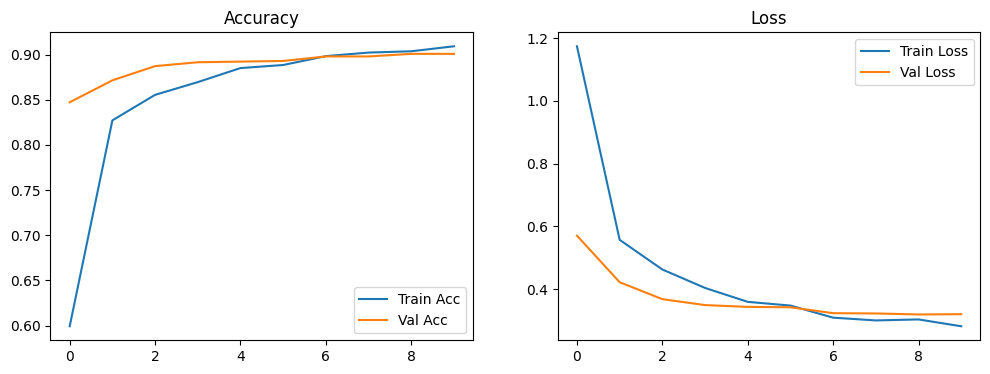

In [36]:

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [38]:
model.save("food_classifier.keras")
print("Model saved as food_classifier.keras")

Model saved as food_classifier.keras
